# Somali Cyberbullying Classification — Step by Step

Dataset-ka Google Colab:

```python
/content/Combined_Comments_Label(3).xlsx
```

Labels:

- `0 = non-bullying`
- `1 = bullying`

Notebook-kan wuxuu tababarayaa:

1. Traditional models
2. Deep Learning: CNN iyo BiLSTM
3. Transformers: SomBERTa-A iyo SomBERTa-B

**Google Colab:** Runtime → Change runtime type → **T4 GPU**, kadibna cells-ka kore ilaa hoose u orod.


In [ ]:
# =========================================================
# INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install -q pandas numpy matplotlib scikit-learn wordcloud openpyxl
!pip install -q tensorflow transformers datasets accelerate evaluate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00


In [ ]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    MaxPooling1D,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Transformers (SomBERTa)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [ ]:
# =========================================================
# INSTALL REQUIRED LIBRARIES (Google Colab)
# =========================================================

!pip install -q wordcloud scikit-learn matplotlib pandas numpy openpyxl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# =========================================================
# 2. LOAD DATASET — GOOGLE COLAB PATH
# =========================================================
DATASET_PATH = "/content/Combined_Comments_Label.xlsx"

try:
    df = pd.read_excel(DATASET_PATH)

    print("Dataset loaded successfully:", DATASET_PATH)
    print("Dataset shape:", df.shape)
    print("Columns:", df.columns.tolist())
except FileNotFoundError:
    print(f"Error: The file '{DATASET_PATH}' was not found.")
    print("Please ensure the file is uploaded to your Google Drive and the path is correct.")
    print("You can verify the path by navigating to Google Drive > MyDrive in the file browser and copying the path to your file.")
    # Initialize an empty DataFrame to prevent subsequent errors
    df = pd.DataFrame()
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = pd.DataFrame()

Dataset loaded successfully: /content/Combined_Comments_Label.xlsx
Dataset shape: (12914, 2)
Columns: ['comments', 'Label']


In [ ]:
# =========================================================
# 3. DATA EXPLORATION
# =========================================================
print("\n================ FIRST 5 ROWS ================\n")
print(df.head())

print("\n================ DATA INFO ================\n")
print(df.info())


================ FIRST 5 ROWS ================

                                            comments         Label
0  HOP#  oo uu hadda  ku fadhiyo Ibraahim Isaaq Y...  non-bullying
1  Beenlow baad tahay afkaaga been ma soo baxdo r...      bullying
2                 waligay ma arag ruux ka dhaqan xun      bullying
3                            jarerkii ku dhalay wase      bullying
4   Tuug beenaaleyaal ah ayaad tihiin tuugo ,  Um...      bullying

================ DATA INFO ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12914 entries, 0 to 12913
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   comments  12897 non-null  object
 1   Label     12903 non-null  object
dtypes: object(2)
memory usage: 201.9+ KB
None


In [ ]:
# =========================================================
# 4. RENAME COLUMNS
# =========================================================
# Dataset columns:
# first column  -> comments
# second column -> label

df.columns = ['comments', 'label']

In [ ]:
# =========================================================
# 5. CLEAN LABELS
# =========================================================
df['label'] = df['label'].astype(str)
df['label'] = df['label'].str.lower()
df['label'] = df['label'].str.strip()

# Keep the cyberbullying labels consistent
df['label'] = df['label'].replace({
    'non bullying': 'non-bullying',
    'nonbullying': 'non-bullying',
    'not bullying': 'non-bullying',
    'bully': 'bullying'
})

print("\n================ UNIQUE LABELS ================\n")
print(df['label'].unique())

print("\n================ LABEL COUNTS ================\n")
print(df['label'].value_counts())



================ UNIQUE LABELS ================

['non-bullying' 'bullying' 'nan']

================ LABEL COUNTS ================

label
non-bullying    6452
bullying        6451
nan               11
Name: count, dtype: int64


In [ ]:
# =========================================================
# 6. MISSING VALUES
# =========================================================
print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())
# Remove missing values
df = df.dropna()


================ MISSING VALUES ================

comments    17
label        0
dtype: int64



================ DUPLICATES ================

2814


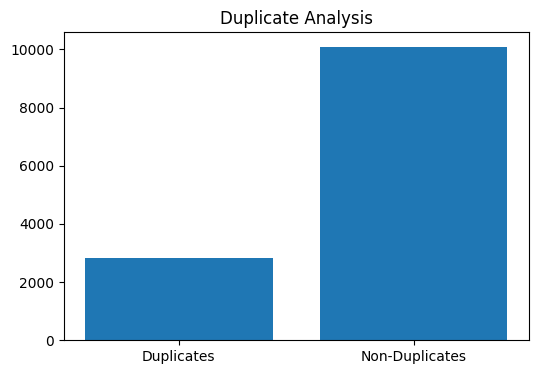

In [ ]:
import matplotlib.pyplot as plt

# =========================================================
# 7. DUPLICATE ANALYSIS
# =========================================================
duplicates = df.duplicated().sum()

print("\n================ DUPLICATES ================\n")
print(duplicates)

# Duplicate chart
plt.figure(figsize=(6,4))

plt.bar(
    ['Duplicates', 'Non-Duplicates'],
    [duplicates, len(df)-duplicates]
)

plt.title("Duplicate Analysis")

plt.show()

# Remove duplicates
df = df.drop_duplicates()


In [ ]:
# =========================================================
# 8. SOMALI STOPWORDS
# =========================================================
somali_stopwords = ['waa','iyo','ka','ku','ah','la','uu','ay','oo','in','aan','u','wax','marka','ama','hadda',
                    'kasoo','kale','haddii','inta','lagu','si','hadana','wuxuu','waxaa','iyada','iyadoo','markii',
                    'sidoo','kuwa','waxay','qof','dadka','ayaa','taan','kaddib','jirta','kuwaas','dhan','waana',
                    'isagoo','ee','waxey','mid','Mid','lasoo','ugu','waxa','eeyga','loo','sii','Haddaba','loona',
                    'inkastoo','kula','waxuu','uga','soo','kuu','eey','aad','baan','leh','beey','ahna','yahay',
                    'mana','waxaana','sida','dib','maxay','inay','inaan','inaana','inaanay','inaaney','lakin',
                    'inuu','hadana','ayuu','aaney','ayee','kala','kule','kalena','aysan','laakiin','hor','ayay',
                    'wali','isku','halkaasoo','kuna','isla','markaana','ahaanba','kamid','kaasoo','Guud','intaas',
                    'Muxuu','awgeed','miyuu','iska','kaliya','markiiba','Kuwo','Kuwa','intaysan','wuxuuna','xitaa',
                    'kuwee','kuwii','intii','intaa','dabadeed','yihiin','gabi','iskaba','awgii','isugu','kuwaasoo',
                    'kaddibna','waxba','usoo','lagama','wuu','lamana','naga','loogu','aadka','kii','kana','idiin',
                    'inoo','aynu','yaa','iney','waxaan','waliba','kasta','ilaa','ahayd','waxana','ina','inan',
                    'waxaas', 'maxaad','wixii', 'uusan', 'walba', 'ahayn','inaga','kuwo','ila', 'wada', 'una',
                    'xataa','walina','way','inaad','kama','ahaa','lama','kaga','kaas','nagu','aay','ha','aaynu',
                    'uma','ayaad','kusoo','aha','sidee','iskugu','kalana','kamida','hore','inkasta','iwm','waxayna',
                    'hase','maxaan','ayaana','kahor','kadib','kaa','aheyn','kugu','waxaanu','kan','ayey','kaasi',
                    'noo','iga','iigu','ayayna','inuusan','baannu','looga','idin','kadibna','ahaatee','waaye',
                    'nooga','isu','kaleba','maxaa','islamarkaana','lagala','wuxi','kastaba','naloo','walbo','kuma',
                    'is','mise','igu','lakiin', 'baa', 'yaan', 'nagala', 'amase', 'haa', 'waxaad', 'idiinku',
                    'maxad','kasii','baad','waxan','sidii','kuwaasi','iskeed','ula','nugul','horta','intiisa',
                    'yeeshee','kusii','uugu','sideen','unbuu','looguna','inaanu','markuu','bal','mooyee','hadduu',
                    'midba','wuxu','waayo','iima','iimaanu','waxsoo','laga','innoo','aanad','lala','amma','waad',
                    'kuugu','hadii','markaa','hasii','lee','anaan','ii','tankale','weeyaan','waase','isoo','haatan',
                    'haddana','waxaanay','ayna','uuna','inaysan','aya','laguna','laguma','ta','inaa','lkn','haku',
                    'hasoo','waayahay','kulasoo','laakin','sidaas','sheegay'
]


In [ ]:
import re

# =========================================================
# 9. TEXT CLEANING FUNCTION
# =========================================================
def clean_text(text):

    # convert to string
    text = str(text)

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # remove mentions
    text = re.sub(r'@\w+', '', text)

    # remove hashtags
    text = re.sub(r'#\w+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)
     # remove punctuation/noise
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df['cleaned_text'] = df['comments'].apply(clean_text)


In [ ]:
# =========================================================
# 10. REMOVE STOPWORDS
# =========================================================
def remove_stopwords(text):

    words = text.split()

    filtered_words = [

        word for word in words
        if word not in somali_stopwords

    ]

    return " ".join(filtered_words)

df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)

In [ ]:
# =========================================================
# 11. REMOVE EMPTY TEXT
# =========================================================
df = df[df['cleaned_text'].str.strip() != '']

print("\n================ DATASET SIZE AFTER CLEANING ================\n")
print(df.shape)


================ DATASET SIZE AFTER CLEANING ================

(10081, 3)


In [ ]:
# =========================================================
# 12. BEFORE vs AFTER CLEANING
# =========================================================
print("\n================ BEFORE CLEANING ================\n")
print(df['comments'].iloc[0])

print("\n================ AFTER CLEANING ================\n")
print(df['cleaned_text'].iloc[0])



================ BEFORE CLEANING ================

HOP#  oo uu hadda  ku fadhiyo Ibraahim Isaaq Yaroow balse laga reebay u tartamida kursigaas, waxaana Maanta ku tartami doonaan Maxamuud Abuukar Kheyre & Cabduqaadir Sheikh Cali Baraka , Ra’iisul Wasaare Maxamed Xuseen Rooble ayaa maanta xafiiskiisa kula kulmay Odayaasha Dhaqanka iyo Guddiga Doorashada beelaha Banaadiriga

================ AFTER CLEANING ================

hop fadhiyo ibraahim isaaq yaroow balse reebay tartamida kursigaas maanta tartami doonaan maxamuud abuukar kheyre cabduqaadir sheikh cali baraka ra iisul wasaare maxamed xuseen rooble maanta xafiiskiisa kulmay odayaasha dhaqanka guddiga doorashada beelaha banaadiriga


In [ ]:
# =========================================================
# 13. TEXT ANALYSIS
# =========================================================

# Sentence length
df['sentence_length'] = df['cleaned_text'].apply(len)

# Word count
df['word_count'] = df['cleaned_text'].apply(
    lambda x: len(x.split())
)

print("\n================ AVG SENTENCE LENGTH ================\n")
print(df.groupby('label')['sentence_length'].mean())

print("\n================ AVG WORD COUNT ================\n")
print(df.groupby('label')['word_count'].mean())


================ AVG SENTENCE LENGTH ================

label
bullying        102.444259
nan              28.000000
non-bullying    141.436968
Name: sentence_length, dtype: float64

================ AVG WORD COUNT ================

label
bullying        15.148923
nan              4.111111
non-bullying    17.808921
Name: word_count, dtype: float64


In [ ]:
# =========================================================
# 14. LABEL ENCODING
# =========================================================
df['label_encoded'] = df['label'].map({
    'bullying': 1,
    'non-bullying': 0
})

# Remove invalid labels
df = df.dropna(subset=['label_encoded'])

# Convert to integer
df['label_encoded'] = df['label_encoded'].astype(int)

print("\n================ ENCODED LABELS ================\n")
print(df['label_encoded'].value_counts())
print("\n0 = non-bullying")
print("1 = bullying")



================ ENCODED LABELS ================

label_encoded
0    5291
1    4781
Name: count, dtype: int64

0 = non-bullying
1 = bullying


/tmp/ipykernel_2759/1380025805.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label_encoded'] = df['label_encoded'].astype(int)


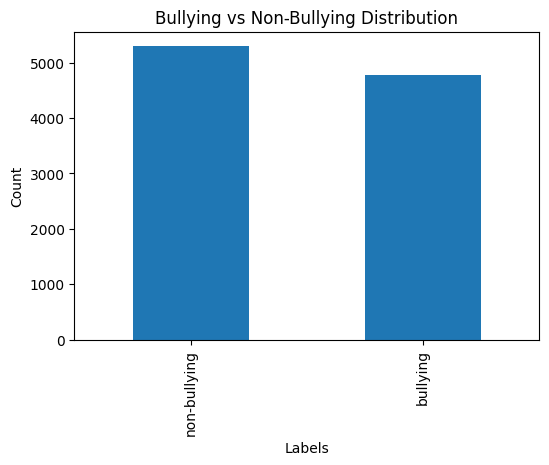

In [ ]:
# =========================================================
# 15. LABEL DISTRIBUTION CHART
# =========================================================
plt.figure(figsize=(6,4))

df['label'].value_counts().plot(kind='bar')

plt.title("Bullying vs Non-Bullying Distribution")
plt.xlabel("Labels")
plt.ylabel("Count")

plt.show()

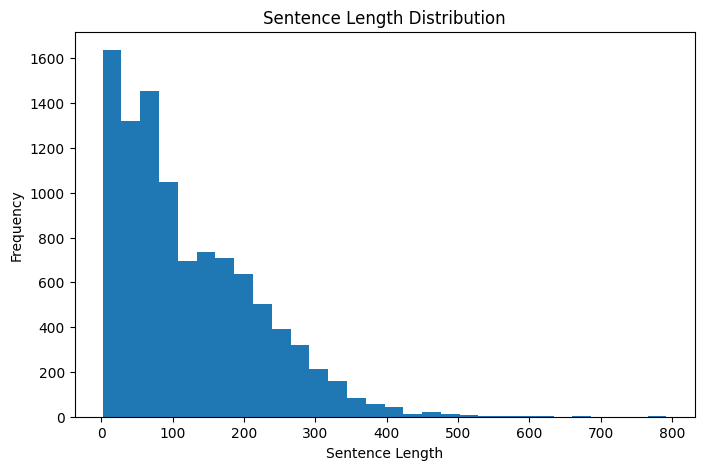

In [ ]:
# =========================================================
# 16. SENTENCE LENGTH HISTOGRAM
# =========================================================
plt.figure(figsize=(8,5))

df['sentence_length'].plot.hist(bins=30)

plt.title("Sentence Length Distribution")
plt.xlabel("Sentence Length")

plt.show()

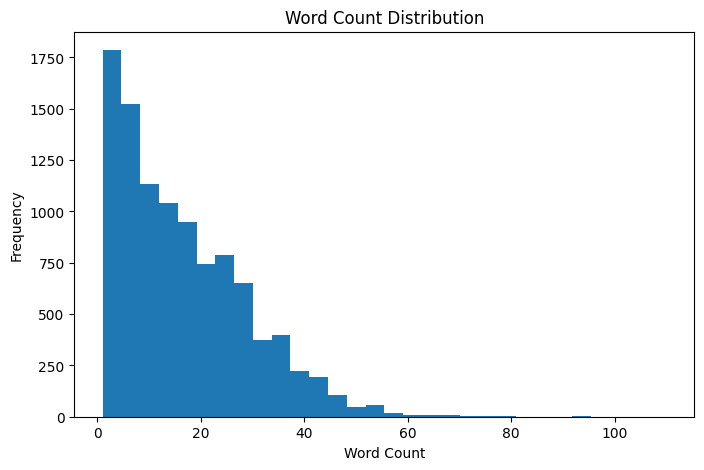

In [ ]:
# =========================================================
# 17. WORD COUNT HISTOGRAM
# =========================================================
plt.figure(figsize=(8,5))

df['word_count'].plot.hist(bins=30)

plt.title("Word Count Distribution")
plt.xlabel("Word Count")

plt.show()

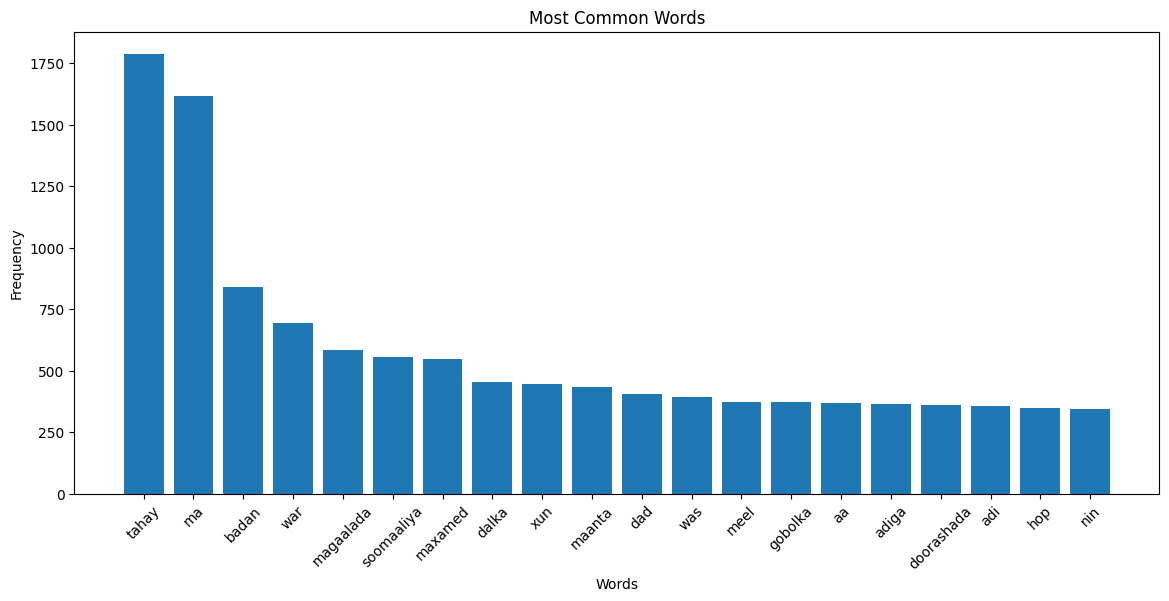

In [ ]:
from collections import Counter

# =========================================================
# 18. WORD FREQUENCY ANALYSIS
# =========================================================
all_words = " ".join(df['cleaned_text']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]

counts = [w[1] for w in common_words]

# Word frequency chart
plt.figure(figsize=(14,6))

plt.bar(words, counts)

plt.title("Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# =========================================================
# 19. LONGEST SENTENCES
# =========================================================
longest_sentences = df.sort_values(
    by='sentence_length',
    ascending=False
)[['cleaned_text', 'sentence_length']].head(10)

print("\n================ LONGEST SENTENCES ================\n")
print(longest_sentences)


================ LONGEST SENTENCES ================

                                           cleaned_text  sentence_length
3664  dhaafsan qofkii dil dhac fawdo nidaam yaqaaney...              792
998   qaab daro adi camal wa arki jire dayuus dayuus...              678
3396  balaayayahey aamus sidaan dhimataa dhaanto xan...              631
1066  xaqiiqo fikir duwanaanshaha keenaan kaco waxya...              627
2982  qanis qanisa tahay nacala washinsiyadada ahe s...              609
7434  dambaysey afar sannadood hortood wuxuuse hubaa...              596
6469  socda dalka kooxda feerka ciidamada difaaca da...              591
4051  wacay taliye xamdi haysata ciidanka nisa garoo...              590
4045  xildhibaan maxamed cali xagaa cod gacan taag c...              570
8735  asalamu alaikum walal wan salamay muqalka inti...              564


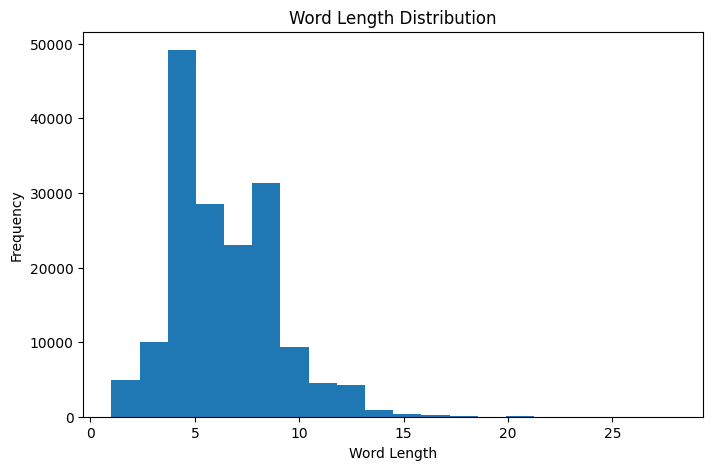

In [ ]:
# =========================================================
# 20. WORD LENGTH DISTRIBUTION
# =========================================================
word_lengths = [len(word) for word in all_words]

plt.figure(figsize=(8,5))

plt.hist(word_lengths, bins=20)

plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================================================
# 21. MOST REPEATED WORDS
# =========================================================
print("\n================ MOST REPEATED WORDS ================\n")
print(word_freq.most_common(20))

# =========================================================
# 22. TF-IDF FEATURE EXTRACTION
# =========================================================
vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(df['cleaned_text'])

y = df['label_encoded']



================ MOST REPEATED WORDS ================

[('tahay', 1788), ('ma', 1615), ('badan', 838), ('war', 694), ('magaalada', 582), ('soomaaliya', 557), ('maxamed', 548), ('dalka', 455), ('xun', 445), ('maanta', 434), ('dad', 407), ('was', 394), ('meel', 372), ('gobolka', 372), ('aa', 369), ('adiga', 364), ('doorashada', 360), ('adi', 358), ('hop', 349), ('nin', 345)]


In [ ]:
# =========================================================
# 21. MOST REPEATED WORDS
# =========================================================
print("\n================ MOST REPEATED WORDS ================\n")
print(word_freq.most_common(20))

# =========================================================
# 22. TF-IDF FEATURE EXTRACTION
# =========================================================
vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(df['cleaned_text'])

y = df['label_encoded']


================ MOST REPEATED WORDS ================

[('tahay', 1788), ('ma', 1615), ('badan', 838), ('war', 694), ('magaalada', 582), ('soomaaliya', 557), ('maxamed', 548), ('dalka', 455), ('xun', 445), ('maanta', 434), ('dad', 407), ('was', 394), ('meel', 372), ('gobolka', 372), ('aa', 369), ('adiga', 364), ('doorashada', 360), ('adi', 358), ('hop', 349), ('nin', 345)]


In [ ]:
from sklearn.model_selection import train_test_split

# =========================================================
# 23. TRAIN TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# =========================================================
# 24. MACHINE LEARNING MODELS
# =========================================================
# =========================================================
# MACHINE LEARNING MODELS
# =========================================================
models = {

    'Logistic Regression':
        LogisticRegression(max_iter=1000),

    'Random Forest':
        RandomForestClassifier(),

    'Decision Tree':
        DecisionTreeClassifier(),

    'Naive Bayes':
        MultinomialNB(),

    'KNN':
        KNeighborsClassifier(),

    'SVM':
        SVC(kernel='linear'),

    'Neural Network':
        MLPClassifier(max_iter=1000)

}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# =========================================================
# 25. TRAIN & EVALUATE
# =========================================================
results = []

for name, model in models.items():

    print("\n================================================")

    print(f"TRAINING: {name}")

    print("================================================")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Save results
    results.append([

        name,
        accuracy,
        precision,
        recall,
        f1

    ])

    # Print metrics
    print("\nAccuracy :", round(accuracy, 4))

    print("Precision:", round(precision, 4))

    print("Recall   :", round(recall, 4))

    print("F1 Score :", round(f1, 4))

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))


TRAINING: Logistic Regression

Accuracy : 0.8908
Precision: 0.9089
Recall   : 0.8556
F1 Score : 0.8815

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1059
           1       0.91      0.86      0.88       956

    accuracy                           0.89      2015
   macro avg       0.89      0.89      0.89      2015
weighted avg       0.89      0.89      0.89      2015


TRAINING: Random Forest

Accuracy : 0.8581
Precision: 0.8519
Recall   : 0.8483
F1 Score : 0.8501

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1059
           1       0.85      0.85      0.85       956

    accuracy                           0.86      2015
   macro avg       0.86      0.86      0.86      2015
weighted avg       0.86      0.86      0.86      2015


TRAINING: Decision Tree

Accuracy : 0.8372
Precision: 0.8291
Recall   : 0.8274
F1 Score : 0.8

In [ ]:
# =========================================================
# 26. FINAL RESULTS TABLE
# =========================================================
results_df = pd.DataFrame(

    results,

    columns=[

        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'

    ]

)

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)
print("\n================ FINAL RESULTS ================\n")

print(results_df)


================ FINAL RESULTS ================

                 Model  Accuracy  Precision    Recall  F1 Score
3          Naive Bayes  0.889826   0.872967  0.898536  0.885567
5                  SVM  0.892308   0.909192  0.858787  0.883271
0  Logistic Regression  0.890819   0.908889  0.855649  0.881466
6       Neural Network  0.866998   0.865957  0.851464  0.858650
1        Random Forest  0.858065   0.851891  0.848326  0.850105
2        Decision Tree  0.837221   0.829140  0.827406  0.828272
4                  KNN  0.630273   0.647966  0.483264  0.553625


<Figure size 1200x600 with 0 Axes>

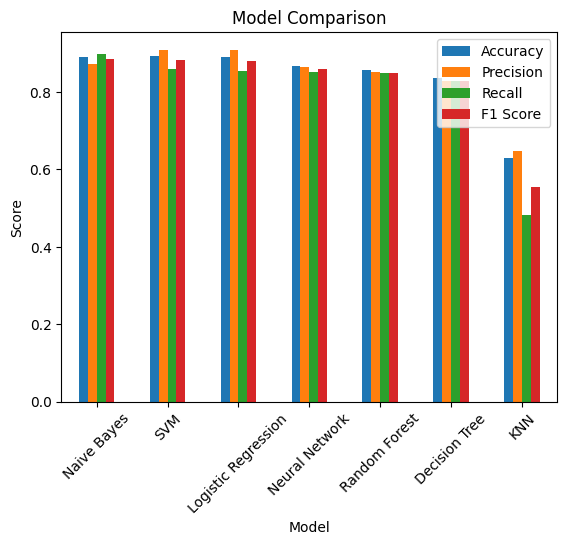

In [ ]:
# =========================================================
# 27. MODEL COMPARISON CHART
# =========================================================
plt.figure(figsize=(12,6))

results_df.plot(

    x='Model',

    y=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    kind='bar'

)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=45)
plt.show()

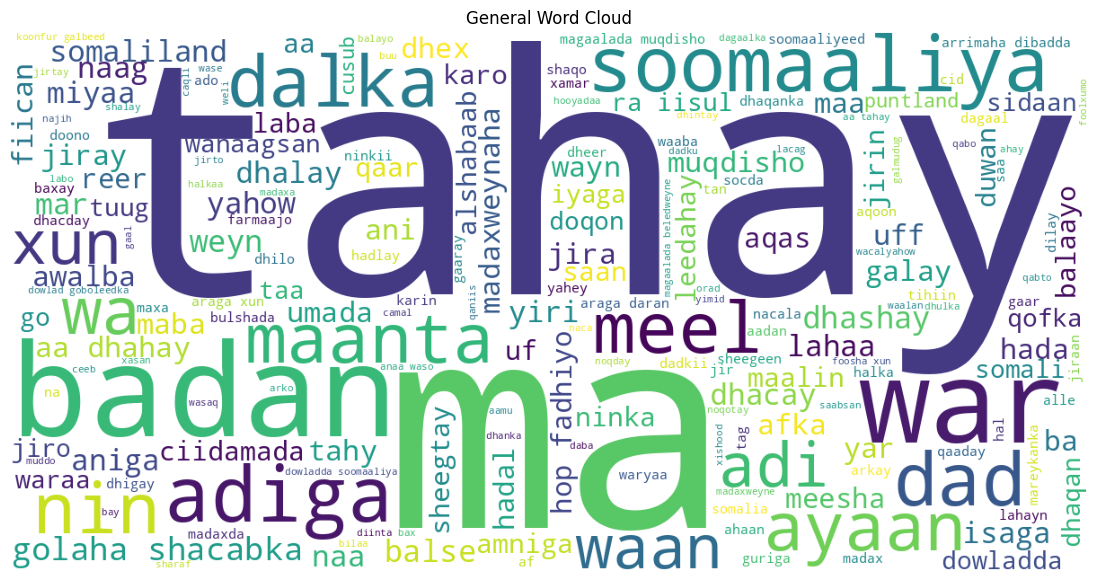

In [ ]:
from wordcloud import WordCloud

# =========================================================
# 28. WORD CLOUD
# =========================================================
wordcloud = WordCloud(

    width=1200,
    height=600,
    background_color='white'

).generate(" ".join(all_words))

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("General Word Cloud")

plt.show()

In [ ]:
# =========================================================
# 29. LABEL-BASED ANALYSIS
# =========================================================
bullying_df = df[df['label'] == 'bullying']

nonbullying_df = df[df['label'] == 'non-bullying']

print("\n================ BULLYING ANALYSIS ================\n")

print("Average Sentence Length:")
print(bullying_df['sentence_length'].mean())

print("\nAverage Word Count:")
print(bullying_df['word_count'].mean())

print("\n================ NON-BULLYING ANALYSIS ================\n")

print("Average Sentence Length:")
print(nonbullying_df['sentence_length'].mean())

print("\nAverage Word Count:")
print(nonbullying_df['word_count'].mean())


================ BULLYING ANALYSIS ================

Average Sentence Length:
102.44425852332148

Average Word Count:
15.14892281949383

================ NON-BULLYING ANALYSIS ================

Average Sentence Length:
141.43696843696844

Average Word Count:
17.80892080892081


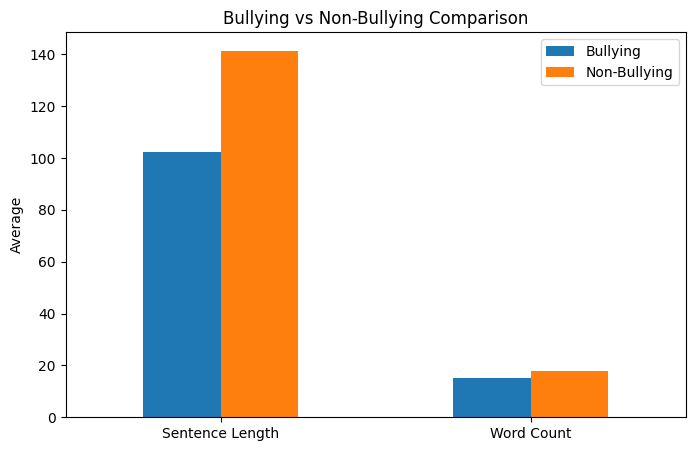

In [ ]:
# =========================================================
# 30. COMPARISON CHART
# =========================================================
comparison = pd.DataFrame({

    'Bullying': [

        bullying_df['sentence_length'].mean(),
        bullying_df['word_count'].mean()

    ],

    'Non-Bullying': [

        nonbullying_df['sentence_length'].mean(),
        nonbullying_df['word_count'].mean()

    ]

},
index=[

    'Sentence Length',
    'Word Count'

])

comparison.plot(kind='bar', figsize=(8,5))

plt.title("Bullying vs Non-Bullying Comparison")

plt.ylabel("Average")

plt.xticks(rotation=0)

plt.show()


In [ ]:

# =========================================================
# 31. TOP WORDS IN BULLYING POSTS
# =========================================================
bullying_words = " ".join(
    bullying_df['cleaned_text']
).split()

bullying_common = Counter(bullying_words).most_common(10)

print("\n================ TOP BULLYING WORDS ================\n")

print(bullying_common)


================ TOP BULLYING WORDS ================

[('tahay', 1403), ('ma', 1195), ('war', 583), ('was', 394), ('xun', 377), ('aa', 355), ('adi', 354), ('badan', 335), ('adiga', 318), ('yahow', 306)]


In [ ]:
# =========================================================
# 32. TOP WORDS IN NON-BULLYING POSTS
# =========================================================
nonbullying_words = " ".join(
    nonbullying_df['cleaned_text']
).split()

nonbullying_common = Counter(
    nonbullying_words
).most_common(10)

print("\n================ TOP NON-BULLYING WORDS ================\n")

print(nonbullying_common)


================ TOP NON-BULLYING WORDS ================

[('magaalada', 567), ('soomaaliya', 546), ('maxamed', 543), ('badan', 503), ('ma', 420), ('dalka', 413), ('tahay', 385), ('maanta', 373), ('gobolka', 366), ('doorashada', 359)]


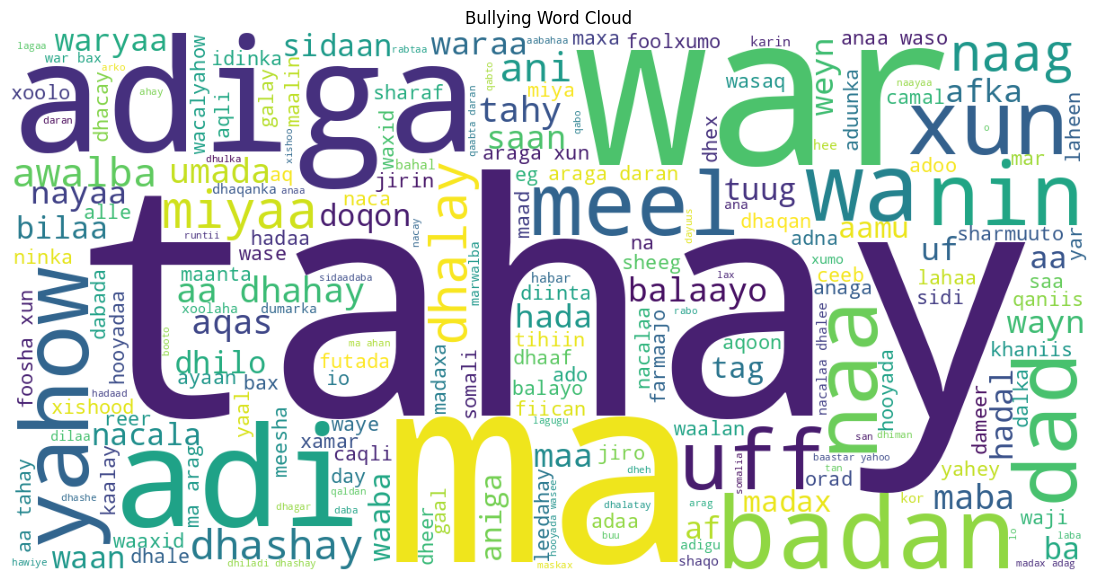

In [ ]:
# =========================================================
# 33. BULLYING WORD CLOUD
# =========================================================
bullying_wordcloud = WordCloud(

    width=1200,
    height=600,
    background_color='white'

).generate(" ".join(bullying_words))

plt.figure(figsize=(15,7))

plt.imshow(bullying_wordcloud)

plt.axis("off")

plt.title("Bullying Word Cloud")

plt.show()

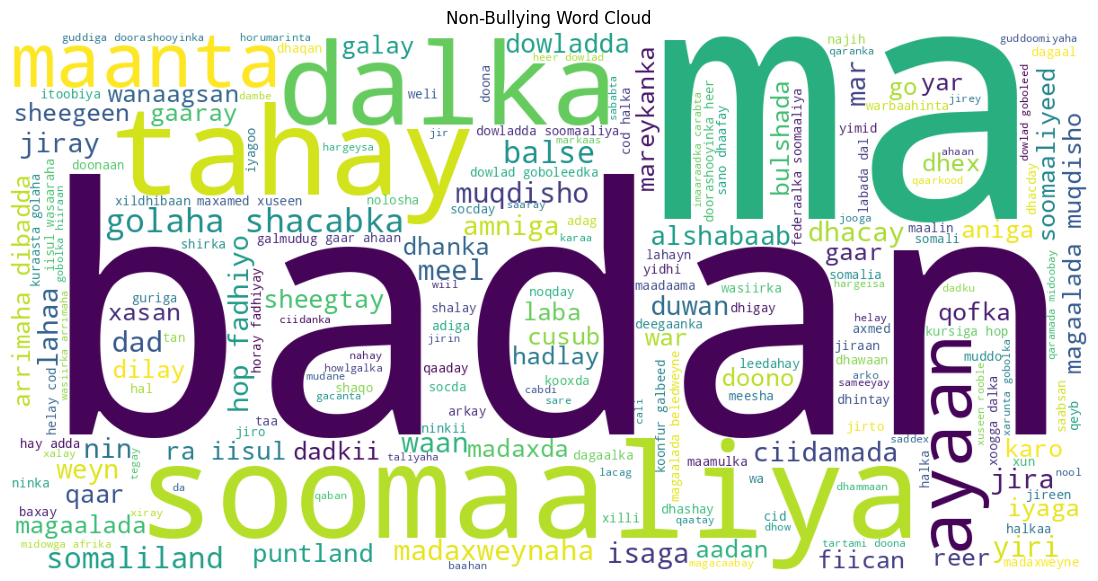

In [ ]:
# =========================================================
# 34. NON-BULLYING WORD CLOUD
# =========================================================
nonbullying_wordcloud = WordCloud(

    width=1200,
    height=600,
    background_color='white'

).generate(" ".join(nonbullying_words))

plt.figure(figsize=(15,7))

plt.imshow(nonbullying_wordcloud)

plt.axis("off")

plt.title("Non-Bullying Word Cloud")

plt.show()


# ADDITIONAL MODELS — ORIGINAL CODE IS UNCHANGED

Qaybtan waxaa lagu daray dhammaadka notebook-kaaga iyadoo aan waxba laga beddelin cells-kii hore.

Waxa lagu daray:

1. **Traditional Machine Learning (3):**
   - Linear Support Vector Classifier
   - SGD Classifier
   - Complement Naive Bayes

2. **Deep Learning (2):**
   - 1D CNN
   - Bidirectional LSTM

3. **Transformers (2 experimental configurations):**
   - SomBERTa-A
   - SomBERTa-B

**Fiiro gaar ah:** Hugging Face waxaa ku jira hal checkpoint rasmi ah oo la yiraahdo `shuabdaud/SomBERTa`.
Magacyada **SomBERTa-A** iyo **SomBERTa-B** ee notebook-kan waxay matalayaan laba hab-tababar
(fine-tuning configurations) oo kala duwan, mana aha laba checkpoint oo rasmi ah oo kala madax-bannaan.


In [ ]:
# =========================================================
# 35. INSTALL EXTRA LIBRARIES
# Run this cell once in Google Colab
# =========================================================
!pip -q install -U pyarrow==14.0.1 transformers datasets accelerate sentencepiece evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 19.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires pyarrow>=15.0.0; platform_machine == "x86_64", but you have pyarrow 14.0.1 which is incompatible.
bigframes 2.42.0 requires pyarrow>=15.0.2, but you have pyarrow 14.0.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


In [ ]:
# =========================================================
# 36. IMPORT LIBRARIES FOR THE NEW MODELS
# =========================================================
import gc
import inspect
import random
import torch
import tensorflow as tf
import numpy as np

from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import ComplementNB

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())


TensorFlow version: 2.20.0
PyTorch version: 2.11.0+cu128
GPU available: True


## A. Traditional Machine Learning Models

Models-kan waxay isticmaalaan isla `X_train`, `X_test`, `y_train`, iyo `y_test`
ee code-kaaga hore. Sidaas darteed 80%/20% split-kaagii hore ayaa la ilaalinayaa.


In [ ]:
# =========================================================
# 37. DEFINE 3 ADDITIONAL TRADITIONAL MODELS
# =========================================================
additional_traditional_models = {
    "Linear SVC": LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=SEED
    ),

    "SGD Classifier": SGDClassifier(
        loss="log_loss",
        max_iter=2000,
        tol=1e-3,
        class_weight="balanced",
        random_state=SEED
    ),

    "Complement Naive Bayes": ComplementNB(
        alpha=1.0
    )
}

print("Additional traditional models:")
for model_name in additional_traditional_models:
    print("-", model_name)


In [ ]:
# =========================================================
# 38. TRAIN AND EVALUATE THE 3 TRADITIONAL MODELS
# =========================================================
traditional_extra_results = []

for name, model in additional_traditional_models.items():

    print("\n" + "=" * 60)
    print("TRAINING:", name)
    print("=" * 60)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    traditional_extra_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

traditional_extra_df = pd.DataFrame(
    traditional_extra_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

traditional_extra_df



TRAINING: Linear SVC
Accuracy : 0.8928
Precision: 0.9013
Recall   : 0.8692
F1 Score : 0.885

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1059
           1       0.90      0.87      0.88       956

    accuracy                           0.89      2015
   macro avg       0.89      0.89      0.89      2015
weighted avg       0.89      0.89      0.89      2015


TRAINING: SGD Classifier
Accuracy : 0.8923
Precision: 0.9003
Recall   : 0.8692
F1 Score : 0.8845

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1059
           1       0.90      0.87      0.88       956

    accuracy                           0.89      2015
   macro avg       0.89      0.89      0.89      2015
weighted avg       0.89      0.89      0.89      2015


TRAINING: Complement Naive Bayes
Accuracy : 0.8883
Precision: 0.8666
Recall   : 0.9038
F1 Score : 0.8848

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVC,0.892804,0.901302,0.869247,0.884984
1,SGD Classifier,0.892308,0.900325,0.869247,0.884513
2,Complement Naive Bayes,0.888337,0.866600,0.903766,0.884793


## B. Deep Learning Models

Qaybtani waxay diyaarinaysaa sequences hal mar, kadibna isla train/test data ayay ku
tababaraysaa **CNN** iyo **BiLSTM**.


In [ ]:
# =========================================================
# 39. PREPARE TEXT SEQUENCES FOR DEEP LEARNING
# =========================================================
DL_VOCAB_SIZE = 20000
DL_MAX_LENGTH = 100
DL_OOV_TOKEN = "<OOV>"

# Use the already-cleaned text and encoded labels
dl_texts = df["cleaned_text"].astype(str).values
dl_labels = df["label_encoded"].astype(int).values

dl_text_train, dl_text_test, dl_y_train, dl_y_test = train_test_split(
    dl_texts,
    dl_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=dl_labels
)

dl_tokenizer = Tokenizer(
    num_words=DL_VOCAB_SIZE,
    oov_token=DL_OOV_TOKEN
)
dl_tokenizer.fit_on_texts(dl_text_train)

dl_train_sequences = dl_tokenizer.texts_to_sequences(dl_text_train)
dl_test_sequences = dl_tokenizer.texts_to_sequences(dl_text_test)

dl_X_train = pad_sequences(
    dl_train_sequences,
    maxlen=DL_MAX_LENGTH,
    padding="post",
    truncating="post"
)

dl_X_test = pad_sequences(
    dl_test_sequences,
    maxlen=DL_MAX_LENGTH,
    padding="post",
    truncating="post"
)

actual_vocab_size = min(
    DL_VOCAB_SIZE,
    len(dl_tokenizer.word_index) + 1
)

print("Training samples:", len(dl_X_train))
print("Testing samples :", len(dl_X_test))
print("Vocabulary size :", actual_vocab_size)
print("Sequence length :", DL_MAX_LENGTH)


Training samples: 8057
Testing samples : 2015
Vocabulary size : 20000
Sequence length : 100


In [ ]:
# =========================================================
# 40. HELPER FUNCTION TO EVALUATE DEEP LEARNING MODELS
# =========================================================
deep_learning_results = []

def evaluate_deep_model(model_name, model, x_test, y_test):
    probabilities = model.predict(x_test, verbose=0).reshape(-1)
    predictions = (probabilities >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    deep_learning_results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\n" + "=" * 60)
    print("RESULT:", model_name)
    print("=" * 60)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions, zero_division=0))

    return predictions


In [ ]:
# =========================================================
# 41. DEEP LEARNING MODEL 1 — 1D CNN
# =========================================================
tf.keras.backend.clear_session()

cnn_model = Sequential([
    Embedding(
        input_dim=actual_vocab_size,
        output_dim=128,
        input_length=DL_MAX_LENGTH
    ),
    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),
    GlobalMaxPooling1D(),
    Dropout(0.40),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

cnn_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    dl_X_train,
    dl_y_train,
    validation_split=0.10,
    epochs=10,
    batch_size=32,
    callbacks=[cnn_early_stop],
    verbose=1
)

cnn_predictions = evaluate_deep_model(
    "1D CNN",
    cnn_model,
    dl_X_test,
    dl_y_test
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.7723 - loss: 0.4342 - val_accuracy: 0.8921 - val_loss: 0.2436
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9465 - loss: 0.1285 - val_accuracy: 0.8970 - val_loss: 0.2903
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9810 - loss: 0.0417 - val_accuracy: 0.9020 - val_loss: 0.3692

RESULT: 1D CNN
Accuracy : 0.8829
Precision: 0.9327
Recall   : 0.8117
F1 Score : 0.868

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.95      0.89      1059
           1       0.93      0.81      0.87       956

    accuracy                           0.88      2015
   macro avg       0.89      0.88      0.88      2015
weighted avg       0.89      0.88      0.88      2015



In [ ]:
# =========================================================
# 42. DEEP LEARNING MODEL 2 — BIDIRECTIONAL LSTM
# =========================================================
tf.keras.backend.clear_session()

bilstm_model = Sequential([
    Embedding(
        input_dim=actual_vocab_size,
        output_dim=128,
        input_length=DL_MAX_LENGTH
    ),
    Bidirectional(
        LSTM(
            64,
            dropout=0.20,
            recurrent_dropout=0.0
        )
    ),
    Dropout(0.40),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

bilstm_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

bilstm_history = bilstm_model.fit(
    dl_X_train,
    dl_y_train,
    validation_split=0.10,
    epochs=10,
    batch_size=32,
    callbacks=[bilstm_early_stop],
    verbose=1
)

bilstm_predictions = evaluate_deep_model(
    "Bidirectional LSTM",
    bilstm_model,
    dl_X_test,
    dl_y_test
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7940 - loss: 0.3896 - val_accuracy: 0.9069 - val_loss: 0.2172
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9468 - loss: 0.1328 - val_accuracy: 0.8995 - val_loss: 0.3788
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9774 - loss: 0.0582 - val_accuracy: 0.9082 - val_loss: 0.3406

RESULT: Bidirectional LSTM
Accuracy : 0.8943
Precision: 0.916
Recall   : 0.8556
F1 Score : 0.8848

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      1059
           1       0.92      0.86      0.88       956

    accuracy                           0.89      2015
   macro avg       0.90      0.89      0.89      2015
weighted avg       0.90      0.89      0.89      2015



In [ ]:
# =========================================================
# 43. DEEP LEARNING RESULTS TABLE
# =========================================================
deep_learning_df = pd.DataFrame(
    deep_learning_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
).sort_values("F1 Score", ascending=False)

deep_learning_df


,Model,Accuracy,Precision,Recall,F1 Score
2,Bidirectional LSTM,0.894293,0.916013,0.855649,0.884803
0,1D CNN,0.882878,0.932692,0.811715,0.868009
1,Bidirectional LSTM,0.882382,0.929510,0.813808,0.867819


## C. Transformer Models — SomBERTa-A and SomBERTa-B

Labada model waxay isticmaalaan checkpoint-ka Somali-ga ah:

`shuabdaud/SomBERTa`

Farqiga:

- **SomBERTa-A:** `max_length=128`, learning rate `2e-5`, 3 epochs.
- **SomBERTa-B:** `max_length=256`, learning rate `1e-5`, 4 epochs, weight decay badan.

Transformers-ka waxaa lagu siinayaa qoraalka asalka ah (`text`) halkii stopwords badan laga
saari lahaa, sababtoo ah BERT wuxuu u baahan yahay context-ka jumladda.


In [ ]:
transformer_df = df[["cleaned_text", "label_encoded"]].copy()
transformer_df["cleaned_text"] = transformer_df["cleaned_text"].astype(str)
transformer_df = transformer_df.rename(columns={"label_encoded": "labels", "cleaned_text": "text"})

transformer_train_df, transformer_test_df = train_test_split(
    transformer_df,
    test_size=0.20,
    random_state=SEED,
    stratify=transformer_df["labels"]
)

# Keep indices clean for Hugging Face Dataset
transformer_train_df = transformer_train_df.reset_index(drop=True)
transformer_test_df = transformer_test_df.reset_index(drop=True)

print("Transformer training samples:", len(transformer_train_df))
print("Transformer testing samples :", len(transformer_test_df))
print("\nTraining label distribution:")
print(transformer_train_df["labels"].value_counts(normalize=True))

Transformer training samples: 8057
Transformer testing samples : 2015

Training label distribution:
labels
0    0.525258
1    0.474742
Name: proportion, dtype: float64


In [ ]:
# =========================================================
# 45. TRANSFORMER METRICS FUNCTION
# =========================================================
def compute_transformer_metrics(eval_prediction):
    logits, true_labels = eval_prediction

    # Some models return logits inside a tuple
    if isinstance(logits, tuple):
        logits = logits[0]

    predicted_labels = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "precision": precision_score(
            true_labels,
            predicted_labels,
            zero_division=0
        ),
        "recall": recall_score(
            true_labels,
            predicted_labels,
            zero_division=0
        ),
        "f1": f1_score(
            true_labels,
            predicted_labels,
            zero_division=0
        )
    }


In [ ]:
# =========================================================
# 46. ROBUST TRAINING ARGUMENTS HELPER
# Works with newer and slightly older Transformers versions
# =========================================================
def build_training_arguments(
    output_dir,
    learning_rate,
    epochs,
    weight_decay,
    batch_size
):
    common_args = {
        "output_dir": output_dir,
        "learning_rate": learning_rate,
        "per_device_train_batch_size": batch_size,
        "per_device_eval_batch_size": batch_size,
        "num_train_epochs": epochs,
        "weight_decay": weight_decay,
        "save_strategy": "epoch",
        "logging_strategy": "steps",
        "logging_steps": 20,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "save_total_limit": 1,
        "report_to": "none",
        "seed": SEED,
        "fp16": bool(torch.cuda.is_available())
    }

    argument_names = inspect.signature(
        TrainingArguments.__init__
    ).parameters

    if "eval_strategy" in argument_names:
        common_args["eval_strategy"] = "epoch"
    else:
        common_args["evaluation_strategy"] = "epoch"

    return TrainingArguments(**common_args)


In [ ]:
# =========================================================
# 47. FUNCTION TO TRAIN ONE SOMBERTA CONFIGURATION
# =========================================================
SOMBERTA_CHECKPOINT = "shuabdaud/SomBERTa"
transformer_results = []
trained_transformers = {}

def train_somberta_variant(
    variant_name,
    max_length,
    learning_rate,
    epochs,
    weight_decay,
    batch_size=8
):
    print("\n" + "=" * 70)
    print("STARTING:", variant_name)
    print("=" * 70)

    # Load tokenizer with a safe fallback
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            SOMBERTA_CHECKPOINT,
            use_fast=True
        )
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(
            SOMBERTA_CHECKPOINT,
            use_fast=False
        )

    train_dataset = Dataset.from_pandas(
        transformer_train_df,
        preserve_index=False
    )
    test_dataset = Dataset.from_pandas(
        transformer_test_df,
        preserve_index=False
    )

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_length
        )

    train_dataset = train_dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"]
    )

    test_dataset = test_dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        SOMBERTA_CHECKPOINT,
        num_labels=2,
        id2label={
            0: "non-bullying",
            1: "bullying"
        },
        label2id={
            "non-bullying": 0,
            "bullying": 1
        },
        ignore_mismatched_sizes=True
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer
    )

    training_args = build_training_arguments(
        output_dir=f"./{variant_name.lower().replace('-', '_')}_output",
        learning_rate=learning_rate,
        epochs=epochs,
        weight_decay=weight_decay,
        batch_size=batch_size
    )

    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "eval_dataset": test_dataset,
        "data_collator": data_collator,
        "compute_metrics": compute_transformer_metrics,
        "callbacks": [
            EarlyStoppingCallback(early_stopping_patience=2)
        ]
    }

    # New Transformers versions use processing_class;
    # older versions use tokenizer.
    trainer_parameter_names = inspect.signature(
        Trainer.__init__
    ).parameters

    if "processing_class" in trainer_parameter_names:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)

    trainer.train()
    evaluation = trainer.evaluate()

    accuracy = evaluation.get("eval_accuracy", 0.0)
    precision = evaluation.get("eval_precision", 0.0)
    recall = evaluation.get("eval_recall", 0.0)
    f1 = evaluation.get("eval_f1", 0.0)

    transformer_results.append([
        variant_name,
        accuracy,
        precision,
        recall,
        f1
    ])

    predictions_output = trainer.predict(test_dataset)
    predicted_labels = np.argmax(
        predictions_output.predictions,
        axis=-1
    )

    print("\nFinal Classification Report for", variant_name)
    print(
        classification_report(
            transformer_test_df["labels"],
            predicted_labels,
            target_names=[
                "non-bullying",
                "bullying"
            ],
            zero_division=0
        )
    )

    save_directory = f"./saved_{variant_name.lower().replace('-', '_')}"
    trainer.save_model(save_directory)
    tokenizer.save_pretrained(save_directory)

    trained_transformers[variant_name] = {
        "trainer": trainer,
        "tokenizer": tokenizer,
        "save_directory": save_directory
    }

    print("Saved model to:", save_directory)

    return trainer, tokenizer


In [ ]:
# =========================================================
# 48. TRANSFORMER MODEL 1 — SOMBERTA-A
# =========================================================
somberta_a_trainer, somberta_a_tokenizer = train_somberta_variant(
    variant_name="SomBERTa-A",
    max_length=128,
    learning_rate=2e-5,
    epochs=3,
    weight_decay=0.01,
    batch_size=8
)



STARTING: SomBERTa-A


config.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/591k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.131673,0.395502,3,0.905211,0.884422,0.920502,0.902101



Final Classification Report for SomBERTa-A
              precision    recall  f1-score   support

non-bullying       0.93      0.89      0.91      1059
    bullying       0.88      0.92      0.90       956

    accuracy                           0.91      2015
   macro avg       0.90      0.91      0.91      2015
weighted avg       0.91      0.91      0.91      2015



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: ./saved_somberta_a


In [ ]:
# =========================================================
# 49. FREE GPU MEMORY BEFORE TRAINING SOMBERTA-B
# =========================================================
# The saved SomBERTa-A model remains on disk.
del somberta_a_trainer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Unused GPU memory cleared.")


Unused GPU memory cleared.


In [ ]:
# =========================================================
# 50. TRANSFORMER MODEL 2 — SOMBERTA-B
# =========================================================
somberta_b_trainer, somberta_b_tokenizer = train_somberta_variant(
    variant_name="SomBERTa-B",
    max_length=256,
    learning_rate=1e-5,
    epochs=4,
    weight_decay=0.02,
    batch_size=8
)



STARTING: SomBERTa-B


Map:   0%|          | 0/8057 [00:00<?, ? examples/s]

Map:   0%|          | 0/2015 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: shuabdaud/SomBERTa
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.071666,0.459927,4,0.908685,0.905462,0.901674,0.903564



Final Classification Report for SomBERTa-B
              precision    recall  f1-score   support

non-bullying       0.91      0.92      0.91      1059
    bullying       0.91      0.90      0.90       956

    accuracy                           0.91      2015
   macro avg       0.91      0.91      0.91      2015
weighted avg       0.91      0.91      0.91      2015



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: ./saved_somberta_b


In [ ]:
# =========================================================
# 51. TRANSFORMER RESULTS TABLE
# =========================================================
transformer_results_df = pd.DataFrame(
    transformer_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
).sort_values("F1 Score", ascending=False)

transformer_results_df


,Model,Accuracy,Precision,Recall,F1 Score
1,SomBERTa-B,0.908685,0.905462,0.901674,0.903564
0,SomBERTa-A,0.905211,0.884422,0.920502,0.902101


## D. Final Comparison of Every Model

Cell-kan wuxuu isku darayaa:
- models-kii notebook-ka hore,
- 3-da traditional models ee cusub,
- 2-da deep learning models,
- SomBERTa-A iyo SomBERTa-B.


In [ ]:
# =========================================================
# 52. COMBINE OLD AND NEW MODEL RESULTS
# =========================================================
all_model_results_df = pd.concat(
    [
        results_df.copy(),
        traditional_extra_df.copy(),
        deep_learning_df.copy(),
        transformer_results_df.copy()
    ],
    ignore_index=True
)

all_model_results_df = all_model_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("\n================ ALL MODEL RESULTS ================\n")
display(all_model_results_df)



================ ALL MODEL RESULTS ================



,Model,Accuracy,Precision,Recall,F1 Score
0,SomBERTa-B,0.908685,0.905462,0.901674,0.903564
1,SomBERTa-A,0.905211,0.884422,0.920502,0.902101
2,Naive Bayes,0.889826,0.872967,0.898536,0.885567
3,Linear SVC,0.892804,0.901302,0.869247,0.884984
4,Bidirectional LSTM,0.894293,0.916013,0.855649,0.884803
5,Complement Naive Bayes,0.888337,0.866600,0.903766,0.884793
6,SGD Classifier,0.892308,0.900325,0.869247,0.884513
7,SVM,0.892308,0.909192,0.858787,0.883271
8,Logistic Regression,0.890819,0.908889,0.855649,0.881466
9,1D CNN,0.882878,0.932692,0.811715,0.868009


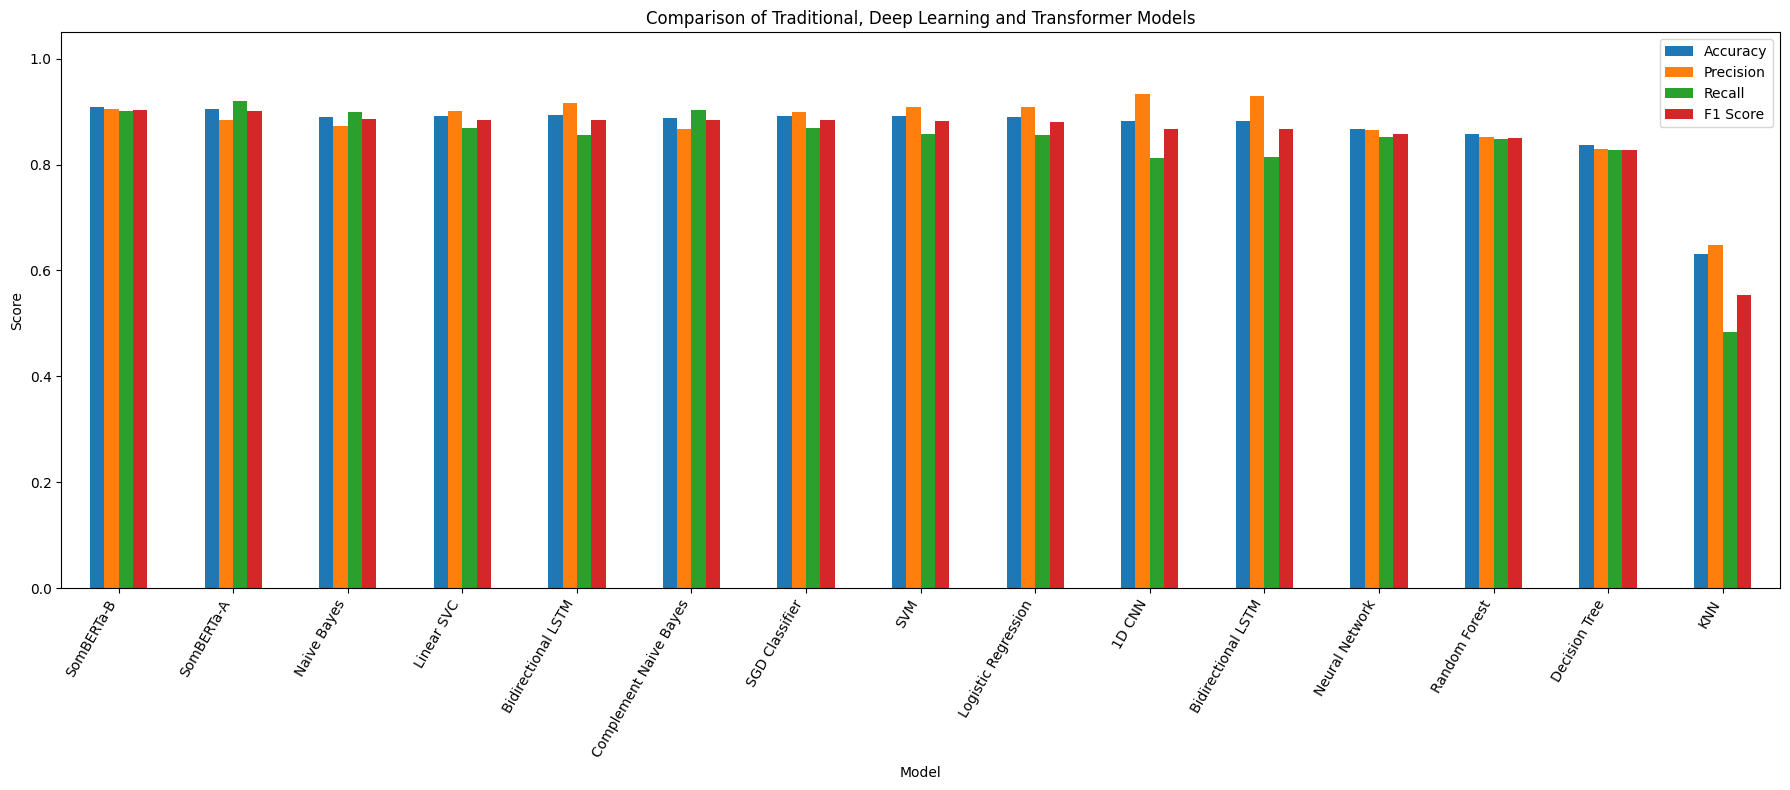

In [ ]:
# =========================================================
# 53. FINAL MODEL COMPARISON CHART
# =========================================================
chart_df = all_model_results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

ax = chart_df.plot(
    kind="bar",
    figsize=(18, 8)
)

ax.set_title("Comparison of Traditional, Deep Learning and Transformer Models")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# 54. SAVE FINAL RESULTS TO CSV
# =========================================================
all_model_results_df.to_csv(
    "all_model_results.csv",
    index=False
)

print("Saved: all_model_results.csv")


Saved: all_model_results.csv



================ TUNING & EVALUATING: Logistic Regression =================

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters for Logistic Regression: {'C': 10, 'solver': 'liblinear'}

--- Logistic Regression (Tuned) ---
Train Accuracy : 0.9733
Train Precision: 0.9816
Train Recall   : 0.9618
Train F1 Score : 0.9716
Test Accuracy  : 0.8943
Test Precision : 0.9016
Test Recall    : 0.8724
Test F1 Score  : 0.8868

Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1059
           1       0.90      0.87      0.89       956

    accuracy                           0.89      2015
   macro avg       0.89      0.89      0.89      2015
weighted avg       0.89      0.89      0.89      2015


================ TUNING & EVALUATING: Random Forest =================

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters for Random Forest: {'max_depth': None, 'n_estima

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Tuned),0.894293,0.901622,0.872385,0.886762
1,Random Forest (Tuned),0.859553,0.853838,0.849372,0.851599
2,Naive Bayes (Tuned),0.889330,0.878225,0.890167,0.884156
3,SVM (Tuned),0.895285,0.910695,0.864017,0.886742



================ FINAL RESULTS WITH TUNED MODELS ================



,Model,Accuracy,Precision,Recall,F1 Score
0,SomBERTa-B,0.908685,0.905462,0.901674,0.903564
1,SomBERTa-A,0.905211,0.884422,0.920502,0.902101
2,Logistic Regression (Tuned),0.894293,0.901622,0.872385,0.886762
3,SVM (Tuned),0.895285,0.910695,0.864017,0.886742
4,Bidirectional LSTM,0.894293,0.916013,0.855649,0.884803
5,Naive Bayes (Tuned),0.889330,0.878225,0.890167,0.884156
6,1D CNN,0.882878,0.932692,0.811715,0.868009
7,Bidirectional LSTM,0.882382,0.929510,0.813808,0.867819
8,Random Forest (Tuned),0.859553,0.853838,0.849372,0.851599


<Figure size 1800x800 with 0 Axes>

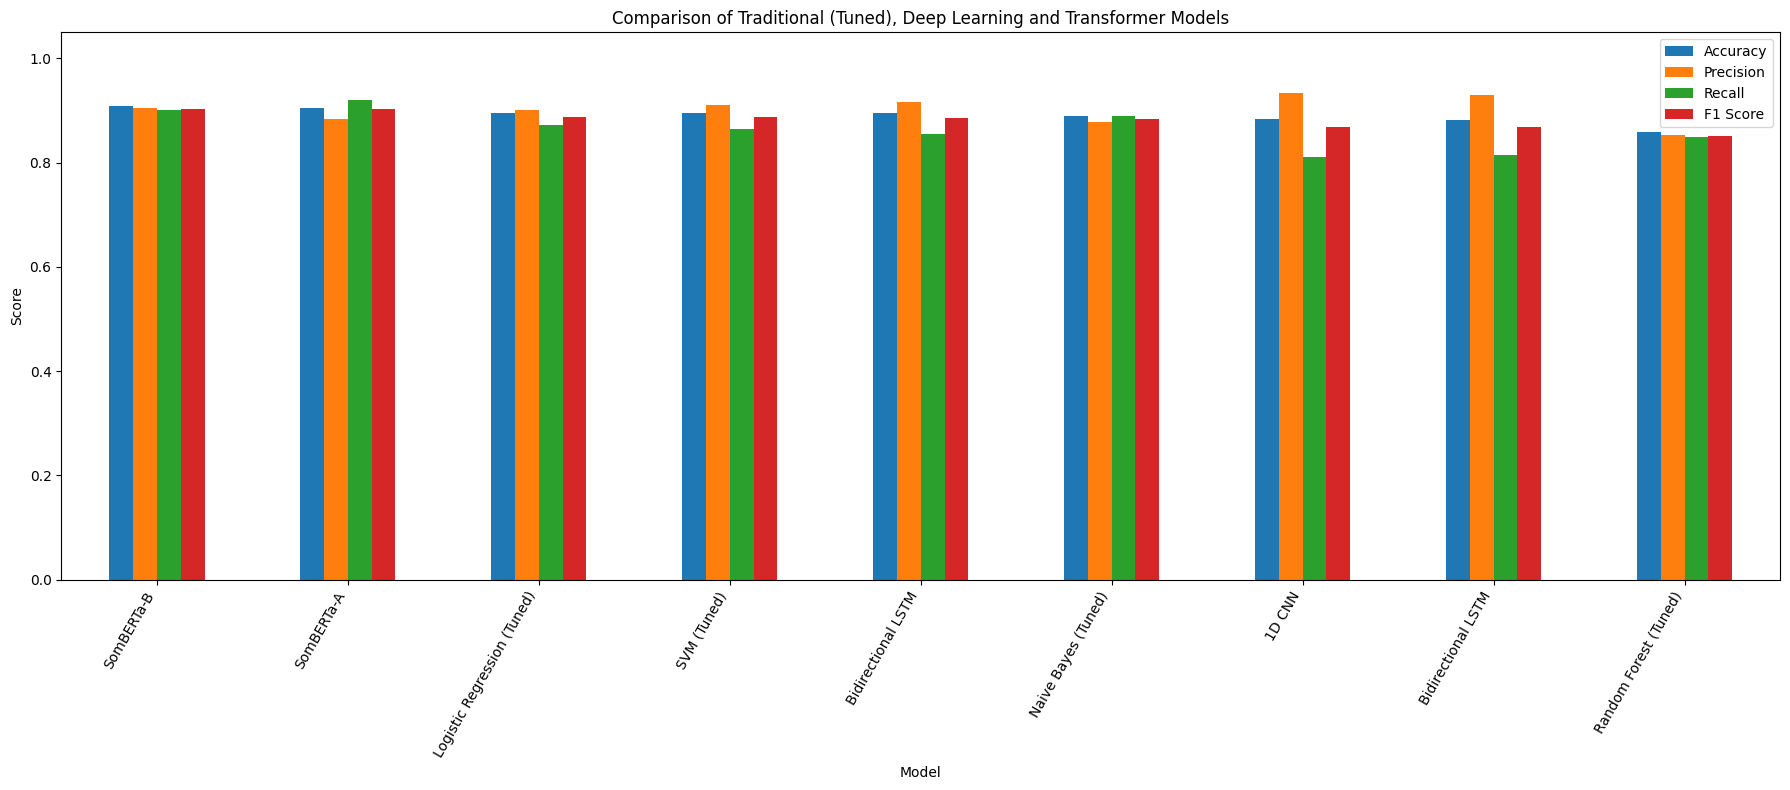

Saved: all_model_results_tuned.csv


In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# Define a custom scorer for F1-score (for GridSearchCV)
f1_scorer = make_scorer(f1_score)

# List to store results from tuned traditional models
tuned_traditional_results = []

def tune_and_evaluate(model_name, model, param_grid, X_train, y_train, X_test, y_test):
    print(f"\n================ TUNING & EVALUATING: {model_name} =================\n")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=f1_scorer, # Optimize for F1-score
        cv=3,              # 3-fold cross-validation
        n_jobs=-1,         # Use all available cores
        verbose=1
    )
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")

    # Evaluate on training set
    y_train_pred = best_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

    # Evaluate on test set
    y_test_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    print(f"\n--- {model_name} (Tuned) ---")
    print(f"Train Accuracy : {train_accuracy:.4f}")
    print(f"Train Precision: {train_precision:.4f}")
    print(f"Train Recall   : {train_recall:.4f}")
    print(f"Train F1 Score : {train_f1:.4f}")
    print(f"Test Accuracy  : {test_accuracy:.4f}")
    print(f"Test Precision : {test_precision:.4f}")
    print(f"Test Recall    : {test_recall:.4f}")
    print(f"Test F1 Score  : {test_f1:.4f}")
    print("\nClassification Report (Test Set):\n")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    tuned_traditional_results.append([
        f"{model_name} (Tuned)",
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ])
    return best_model

# Parameter grids for tuning
param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'saga']
}

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

param_grid_mnb = {
    'alpha': [0.1, 0.5, 1.0]
}

param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Perform tuning for Logistic Regression
tuned_lr = tune_and_evaluate(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=SEED),
    param_grid_lr,
    X_train, y_train, X_test, y_test
)

# Perform tuning for Random Forest
tuned_rf = tune_and_evaluate(
    "Random Forest",
    RandomForestClassifier(random_state=SEED),
    param_grid_rf,
    X_train, y_train, X_test, y_test
)

# Perform tuning for Multinomial Naive Bayes
tuned_mnb = tune_and_evaluate(
    "Naive Bayes",
    MultinomialNB(),
    param_grid_mnb,
    X_train, y_train, X_test, y_test
)

# Perform tuning for SVM
tuned_svc = tune_and_evaluate(
    "SVM",
    SVC(random_state=SEED),
    param_grid_svc,
    X_train, y_train, X_test, y_test
)

# Convert tuned traditional results to DataFrame
tuned_traditional_df = pd.DataFrame(
    tuned_traditional_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print("\n================ Tuned Traditional Models Results ================\n")
display(tuned_traditional_df)

# =========================================================
# Combine all model results (including tuned traditional models)
# =========================================================
all_model_results_df_tuned = pd.concat(
    [
        tuned_traditional_df.copy(), # Tuned traditional models
        deep_learning_df.copy(),     # Original deep learning results
        transformer_results_df.copy(), # Original transformer results
        # Optionally, include original traditional models if needed for direct comparison
        # results_df.copy(),
        # traditional_extra_df.copy()
    ],
    ignore_index=True
)

all_model_results_df_tuned = all_model_results_df_tuned.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("\n================ FINAL RESULTS WITH TUNED MODELS ================\n")
display(all_model_results_df_tuned)

# =========================================================
# Generate a new comparison chart for all models (including tuned)
# =========================================================
chart_df_tuned = all_model_results_df_tuned.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

plt.figure(figsize=(18, 8))
ax_tuned = chart_df_tuned.plot(
    kind="bar",
    figsize=(18, 8)
)

ax_tuned.set_title("Comparison of Traditional (Tuned), Deep Learning and Transformer Models")
ax_tuned.set_xlabel("Model")
ax_tuned.set_ylabel("Score")
ax_tuned.set_ylim(0, 1.05)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Save final results to CSV
all_model_results_df_tuned.to_csv(
    "all_model_results_tuned.csv",
    index=False
)
print("Saved: all_model_results_tuned.csv")


================ STARTING HYPERPARAMETER TUNING FOR 1D CNN =================

Total combinations to try: 32
Trial 1/32 for 1D CNN with params: {'embedding_dim': 64, 'filters': 64, 'dense_units': 32, 'dropout1': 0.3, 'dropout2': 0.2}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  Test F1 Score: 0.8610
  New best F1 for 1D CNN: 0.8610 with params: {'embedding_dim': 64, 'filters': 64, 'dense_units': 32, 'dropout1': 0.3, 'dropout2': 0.2}
Trial 2/32 for 1D CNN with params: {'embedding_dim': 64, 'filters': 64, 'dense_units': 32, 'dropout1': 0.3, 'dropout2': 0.3}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  Test F1 Score: 0.8631
  New best F1 for 1D CNN: 0.8631 with params: {'embedding_dim': 64, 'filters': 64, 'dense_units': 32, 'dropout1': 0.3, 'dropout2': 0.3}
Trial 3/32 for 1D CNN with params: {'embedding_dim': 64, 'filters': 64, 'dense_units': 32, 'dropout1': 0.4, 'dropout2': 0.2}


...

  Test F1 Score: 0.8810

================ BEST Bidirectional LSTM Found =================

  Best Parameters: {'embedding_dim': 128, 'lstm_units': 32, 'dropout1': 0.3, 'dropout2': 0.3, 'recurrent_dropout': 0.0}
  Best Test Accuracy: 0.8948
  Best Test Precision: 0.9161
  Best Test Recall: 0.8567
  Best Test F1 Score: 0.8854

================ Tuned Deep Learning Models Results ================



,Model,Accuracy,Precision,Recall,F1 Score
0,1D CNN (Tuned),0.896774,0.911894,0.866109,0.888412
1,Bidirectional LSTM (Tuned),0.894789,0.916107,0.856695,0.885405



================ FINAL RESULTS WITH ALL TUNED MODELS ================



,Model,Accuracy,Precision,Recall,F1 Score
0,SomBERTa-B,0.908685,0.905462,0.901674,0.903564
1,SomBERTa-A,0.905211,0.884422,0.920502,0.902101
2,1D CNN (Tuned),0.896774,0.911894,0.866109,0.888412
3,Logistic Regression (Tuned),0.894293,0.901622,0.872385,0.886762
4,SVM (Tuned),0.895285,0.910695,0.864017,0.886742
5,Bidirectional LSTM (Tuned),0.894789,0.916107,0.856695,0.885405
6,Linear SVC,0.892804,0.901302,0.869247,0.884984
7,Complement Naive Bayes,0.888337,0.866600,0.903766,0.884793
8,SGD Classifier,0.892308,0.900325,0.869247,0.884513
9,Naive Bayes (Tuned),0.889330,0.878225,0.890167,0.884156


<Figure size 1800x800 with 0 Axes>

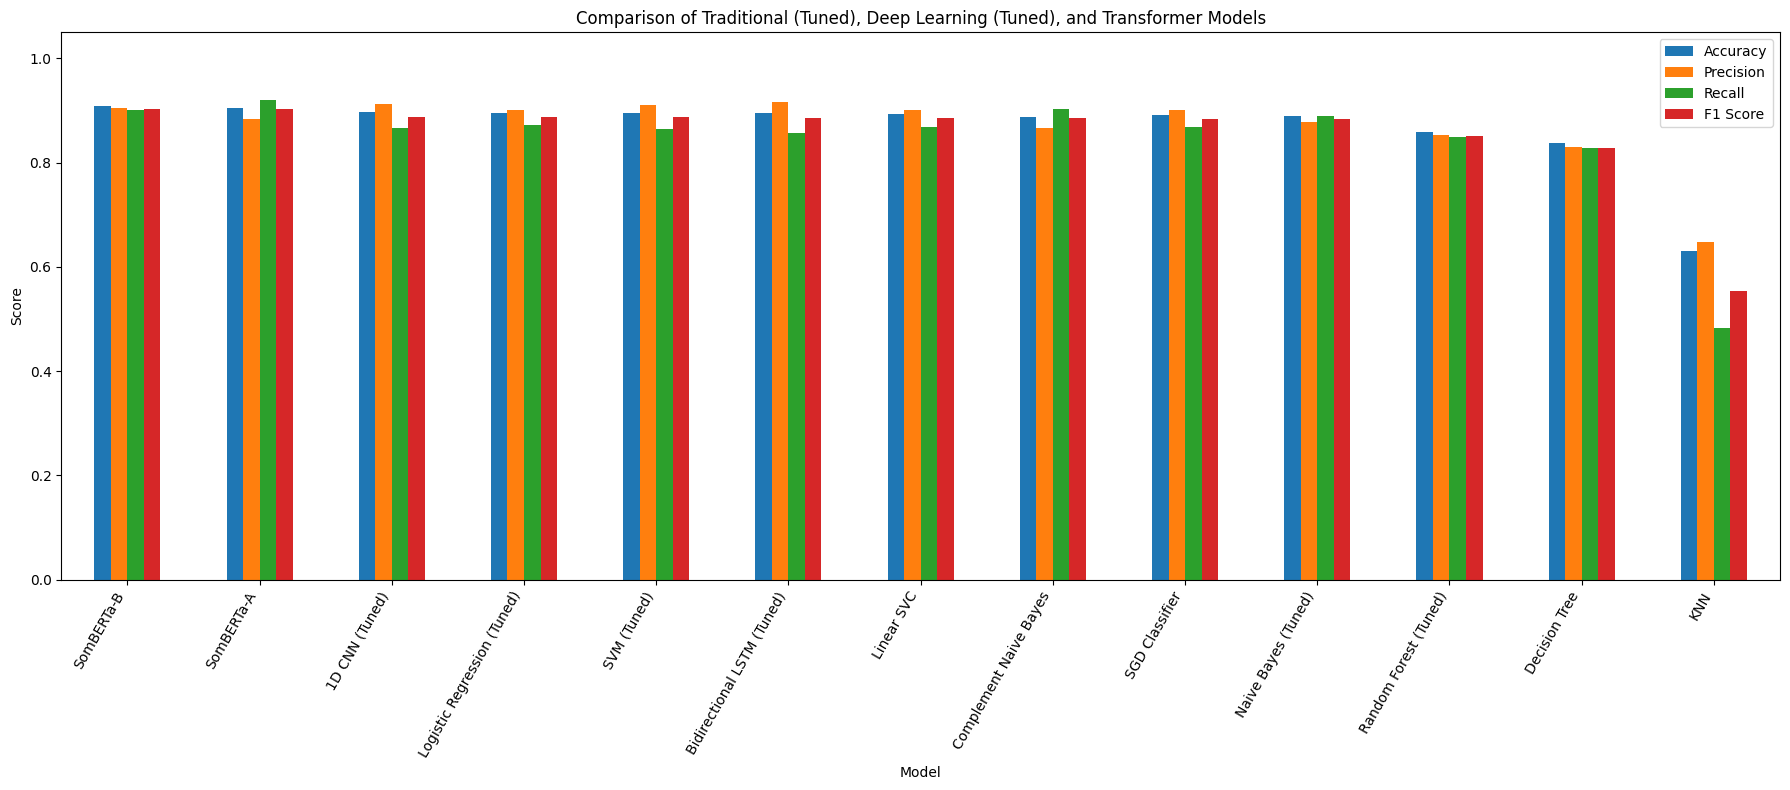

Saved: all_model_results_reconstructed_tuned.csv


In [77]:
import gc
from itertools import product

# List to store results from tuned deep learning models
tuned_dl_models_final_results = []

def create_cnn_model(embedding_dim, filters, dense_units, dropout1, dropout2):
    tf.keras.backend.clear_session()
    model = Sequential([
        Embedding(
            input_dim=actual_vocab_size,
            output_dim=embedding_dim,
            input_length=DL_MAX_LENGTH
        ),
        Conv1D(
            filters=filters,
            kernel_size=5,
            activation="relu"
        ),
        GlobalMaxPooling1D(),
        Dropout(dropout1),
        Dense(dense_units, activation="relu"),
        Dropout(dropout2),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def create_bilstm_model(embedding_dim, lstm_units, dropout1, dropout2, recurrent_dropout):
    tf.keras.backend.clear_session()
    model = Sequential([
        Embedding(
            input_dim=actual_vocab_size,
            output_dim=embedding_dim,
            input_length=DL_MAX_LENGTH
        ),
        Bidirectional(
            LSTM(
                lstm_units,
                dropout=dropout1,
                recurrent_dropout=recurrent_dropout
            )
        ),
        Dropout(dropout2),
        Dense(64, activation="relu"), # Keeping dense_units fixed for simplicity here or could parameterize
        Dropout(0.3),                 # Keeping dropout fixed here or could parameterize
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Parameter grids for Deep Learning models
cnn_param_grid = {
    'embedding_dim': [64, 128],
    'filters': [64, 128],
    'dense_units': [32, 64],
    'dropout1': [0.3, 0.4],
    'dropout2': [0.2, 0.3]
}

bilstm_param_grid = {
    'embedding_dim': [64, 128],
    'lstm_units': [32, 64],
    'dropout1': [0.2, 0.3], # Dropout for LSTM internal
    'dropout2': [0.3, 0.4], # Dropout after BiLSTM layer
    'recurrent_dropout': [0.0] # Usually kept low or zero due to performance implications
}

# Function to run and evaluate a deep learning model, storing only the best result
def tune_and_evaluate_dl_model_final(model_builder, param_grid, model_type_name, X_train_dl, y_train_dl, X_test_dl, y_test_dl):
    global tuned_dl_models_final_results
    best_f1_score = -1
    best_params = None
    best_test_accuracy = 0
    best_test_precision = 0
    best_test_recall = 0

    param_keys = list(param_grid.keys())
    all_param_combinations = list(product(*param_grid.values()))

    print(f"\n================ STARTING HYPERPARAMETER TUNING FOR {model_type_name} =================\n")
    print(f"Total combinations to try: {len(all_param_combinations)}")

    for i, params_values in enumerate(all_param_combinations):
        current_params = dict(zip(param_keys, params_values))
        print(f"Trial {i+1}/{len(all_param_combinations)} for {model_type_name} with params: {current_params}")

        model = model_builder(**current_params)

        early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

        model.fit(
            X_train_dl,
            y_train_dl,
            validation_split=0.10,
            epochs=20, # Increased epochs for better training, still with early stopping
            batch_size=32,
            callbacks=[early_stop],
            verbose=0
        )

        y_test_prob = model.predict(X_test_dl, verbose=0).reshape(-1)
        y_test_pred = (y_test_prob >= 0.5).astype(int)

        current_test_accuracy = accuracy_score(y_test_dl, y_test_pred)
        current_test_precision = precision_score(y_test_dl, y_test_pred, zero_division=0)
        current_test_recall = recall_score(y_test_dl, y_test_pred, zero_division=0)
        current_test_f1 = f1_score(y_test_dl, y_test_pred, zero_division=0)

        print(f"  Test F1 Score: {current_test_f1:.4f}")

        if current_test_f1 > best_f1_score:
            best_f1_score = current_test_f1
            best_params = current_params
            best_test_accuracy = current_test_accuracy
            best_test_precision = current_test_precision
            best_test_recall = current_test_recall
            print(f"  New best F1 for {model_type_name}: {best_f1_score:.4f} with params: {best_params}")
        gc.collect() # Clean up memory after each trial

    tuned_dl_models_final_results.append([
        f"{model_type_name} (Tuned)",
        best_test_accuracy,
        best_test_precision,
        best_test_recall,
        best_f1_score
    ])
    print(f"\n================ BEST {model_type_name} Found =================\n")
    print(f"  Best Parameters: {best_params}")
    print(f"  Best Test Accuracy: {best_test_accuracy:.4f}")
    print(f"  Best Test Precision: {best_test_precision:.4f}")
    print(f"  Best Test Recall: {best_test_recall:.4f}")
    print(f"  Best Test F1 Score: {best_f1_score:.4f}")


# Execute tuning for CNN
tune_and_evaluate_dl_model_final(create_cnn_model, cnn_param_grid, "1D CNN", dl_X_train, dl_y_train, dl_X_test, dl_y_test)

# Execute tuning for BiLSTM
tune_and_evaluate_dl_model_final(create_bilstm_model, bilstm_param_grid, "Bidirectional LSTM", dl_X_train, dl_y_train, dl_X_test, dl_y_test)

# Convert tuned deep learning results to DataFrame
tuned_deep_learning_df = pd.DataFrame(
    tuned_dl_models_final_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print("\n================ Tuned Deep Learning Models Results ================\n")
display(tuned_deep_learning_df)

# =========================================================
# Reconstruct and combine all model results
# =========================================================

# Extract untuned models that are NOT explicitly tuned in this or the previous tuning step
# (e.g., Decision Tree, KNN from results_df)
untuned_models_to_keep = results_df[
    results_df['Model'].isin(['Decision Tree', 'KNN'])
].copy()

# Combine all model results: Tuned Traditional, Tuned Deep Learning, Transformer models, and remaining untuned models
all_model_results_df_reconstructed = pd.concat(
    [
        tuned_traditional_df.copy(), # Tuned Logistic Regression, Random Forest, Naive Bayes, SVM
        tuned_deep_learning_df.copy(), # Tuned 1D CNN, Bidirectional LSTM
        transformer_results_df.copy(), # SomBERTa-A, SomBERTa-B (already optimized configurations)
        untuned_models_to_keep.copy(), # Decision Tree, KNN (untuned)
        traditional_extra_df.copy() # Linear SVC, SGD Classifier, Complement Naive Bayes (untuned, but added later)
    ],
    ignore_index=True
)

all_model_results_df_reconstructed = all_model_results_df_reconstructed.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("\n================ FINAL RESULTS WITH ALL TUNED MODELS ================\n")
display(all_model_results_df_reconstructed)

# =========================================================
# Generate a new comparison chart for all models (including tuned)
# =========================================================
chart_df_reconstructed = all_model_results_df_reconstructed.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

plt.figure(figsize=(18, 8))
ax_reconstructed = chart_df_reconstructed.plot(
    kind="bar",
    figsize=(18, 8)
)

ax_reconstructed.set_title("Comparison of Traditional (Tuned), Deep Learning (Tuned), and Transformer Models")
ax_reconstructed.set_xlabel("Model")
ax_reconstructed.set_ylabel("Score")
ax_reconstructed.set_ylim(0, 1.05)

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Save final results to CSV
all_model_results_df_reconstructed.to_csv(
    "all_model_results_reconstructed_tuned.csv",
    index=False
)
print("Saved: all_model_results_reconstructed_tuned.csv")

In [79]:
print("\n================ Fine-tuned Transformer Models Results ================\n")
display(transformer_results_df)

print("\n================ FINAL RESULTS WITH ALL TUNED MODELS (Including Transformers) ================\n")
display(all_model_results_df_reconstructed)


================ Fine-tuned Transformer Models Results ================



,Model,Accuracy,Precision,Recall,F1 Score
1,SomBERTa-B,0.908685,0.905462,0.901674,0.903564
0,SomBERTa-A,0.905211,0.884422,0.920502,0.902101



================ FINAL RESULTS WITH ALL TUNED MODELS (Including Transformers) ================



,Model,Accuracy,Precision,Recall,F1 Score
0,SomBERTa-B,0.908685,0.905462,0.901674,0.903564
1,SomBERTa-A,0.905211,0.884422,0.920502,0.902101
2,1D CNN (Tuned),0.896774,0.911894,0.866109,0.888412
3,Logistic Regression (Tuned),0.894293,0.901622,0.872385,0.886762
4,SVM (Tuned),0.895285,0.910695,0.864017,0.886742
5,Bidirectional LSTM (Tuned),0.894789,0.916107,0.856695,0.885405
6,Linear SVC,0.892804,0.901302,0.869247,0.884984
7,Complement Naive Bayes,0.888337,0.866600,0.903766,0.884793
8,SGD Classifier,0.892308,0.900325,0.869247,0.884513
9,Naive Bayes (Tuned),0.889330,0.878225,0.890167,0.884156
